# MountainCar RL — Tinder for RL (RLI 22.00)

> Group assignment, Part 01.
> Authors: _TBD — fill in_

This notebook is the **single deliverable for Part 01**. It loads pre-trained
results (mode `cache`, default) or retrains live (modes `demo` / `full`) and
narrates the analysis paper-style. All implementation lives in the
`src/mountaincar_rl/` package — this file is the orchestrator.

---

## §0 · Setup

We pin three runtime modes, controlled by `MODE` below:

| Mode | What it does | Time |
|---|---|---|
| `cache` (default) | Load cached `artifacts/results/*.json` + `artifacts/figures/*.png` | ~30 s |
| `demo` | Train every algo with reduced budget (1 seed × 5k steps) | ≤5 min |
| `full` | Train 3 seeds × 30k steps; regenerates the cache | ~15–18 min |

The `!pip install` cell below is for graders running the notebook directly
in any clean Python 3.13 venv (the prof's standalone-reproducibility
requirement, PDF p7). If you set up via `make install` (uv) you can skip it.

In [1]:
# Standalone install path (skip if you used `make install`).
# Pinned versions live in requirements.txt at the project root.
import sys, subprocess
INSTALL_DEPS = False  # set to True if running outside the uv-managed env
if INSTALL_DEPS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "-r", "../../../requirements.txt"])

**External libraries used (with purpose):**

- **gymnasium** — RL environments (`MountainCar-v0`, `MountainCarContinuous-v0`)
- **stable-baselines3** — production-grade implementations of DQN, PPO, SAC
- **torch** — neural network backend (SB3 dependency)
- **tensorboard** — training metric monitoring (`make tensorboard`)
- **scikit-learn** — surrogate trees + permutation importance for interpretability
- **matplotlib / seaborn** — plotting
- **tqdm / rich** — progress bars + nice console tables
- **numpy / pandas** — numerical computation

All deps are pinned in `requirements.txt` (regenerable via `make requirements`).

In [2]:
# Run mode + execution config
MODE = "cache"   # "cache" | "demo" | "full"

# Imports — everything we need lives in our package
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable when this notebook is opened directly without `pip install -e .`
import sys
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mountaincar_rl import config
from mountaincar_rl.envs import Scenario, make_env
from mountaincar_rl.envs.scenarios import SPECS, discrete_scenarios, continuous_scenarios
from mountaincar_rl.agents import make_agent
from mountaincar_rl.agents.factory import is_tabular
from mountaincar_rl.training import train_tabular, train_deep
from mountaincar_rl.training.multi_seed import run_one, ALGO_SCENARIOS, GROUPS, DEFAULT_SHAPING
from mountaincar_rl.evaluation import load_results, aggregate_seeds, evaluate_agent
from mountaincar_rl.evaluation.statistics import smoothed_mean_std
from mountaincar_rl.analysis import (
    extract_action_grid, extract_value_grid, rollout_trajectory,
    fit_surrogate_tree, feature_importance,
    potential_energy, kinetic_energy, total_energy, energy_grid,
)
from mountaincar_rl.analysis.physics import natural_frequency, natural_period
from mountaincar_rl.viz import (
    action_heatmap, visitation_heatmap, value_surface,
    phase_portrait, learning_curves, compare_policies,
)

print(f"MODE = {MODE!r}")
print(f"Project root: {ROOT}")
print(f"Cached results in: {config.RESULTS_DIR.relative_to(ROOT)}")

MODE = 'cache'
Project root: /Users/javierdominguezsegura/Academics/College/Courses/RL/Group Project
Cached results in: artifacts/results


---

## §1 · Executive summary

**Problem.** MountainCar (Moore, 1990) — an under-powered car must escape a
sinusoidal valley. Crucially, gravity overpowers the engine, so a greedy
"throttle right" policy *fails*. The agent must discover an oscillation
strategy: build potential energy by reversing up the left hill, then convert
it to kinetic energy by accelerating right.

**Approach.** We treat MountainCar as a **policy-discovery testbed** and
study how 5 algorithms (Q-learning, SARSA, DQN, PPO, SAC) discover this
strategy across **4 scenario variants** (discrete/continuous × min-steps/min-fuel)
and 5 reward-shaping schemes. We frame the problem physically as a
**Forced Harmonic Oscillator** (PDF appendix), with characteristic
period ≈ 72 env steps, against which we benchmark learned policies.

**Findings (preview — filled in after full run).** _TBD: per-algo headline
numbers (mean ± std reward, success rate), the qualitative differences in
discovered policies, and the connection to FHO physics._

<!-- TODO[analysis: §1 executive summary] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Pull headline numbers from artifacts/results/._

---

## §2 · Problem framing

### 2.1 The MDP

| Element | Specification |
|---|---|
| **State** $s = (x, v)$ | $x \in [-1.2, 0.6]$, $v \in [-0.07, 0.07]$ |
| **Action** (discrete) | $\{0, 1, 2\}$ = {left, no-op, right} |
| **Action** (continuous) | $a \in [-1, 1]$, scaled by `power=0.0015` |
| **Transition** | $v' = v + (a-1) \cdot F - \cos(3x) \cdot G$, $\;x' = x + v'$ |
| **Reward** (default discrete) | $-1$ per step |
| **Reward** (default continuous) | $-0.1\,a^2$ per step, $+100$ on goal |
| **Goal** | $x \geq 0.5$ |
| **Termination** | goal reached, or 200 steps (discrete) / 999 steps (continuous) |

with $F = 0.001$, $G = 0.0025$.

### 2.2 The 4 scenarios (PDF p17)

|             | **Min steps**                 | **Min fuel**                            |
|-------------|-------------------------------|-----------------------------------------|
| Discrete    | (1) `MountainCar-v0`          | (3) `MountainCar-v0` + fuel-cost wrapper|
| Continuous  | (4) `MCC-v0` + steps wrapper  | (2) `MountainCarContinuous-v0`          |

### 2.3 Forced Harmonic Oscillator framing

The transition $\dot v = (a-1)F - G\cos(3x)$ for small $x$ behaves like
$\ddot x \approx -3G\,x + (a-1)F$ — a linear oscillator forced by the
control. Natural frequency $\omega = \sqrt{3G}$, period $T = 2\pi/\omega$.

In [3]:
ω = natural_frequency()
T = natural_period()
print(f"Linearized natural frequency  ω = {ω:.4f} rad/step")
print(f"Linearized natural period     T = {T:.1f} env-steps")
print(f"Episode horizon (discrete)    = 200 steps  → ~{200/T:.2f} natural periods")
print(f"Episode horizon (continuous)  = 999 steps  → ~{999/T:.2f} natural periods")

Linearized natural frequency  ω = 0.0866 rad/step
Linearized natural period     T = 72.6 env-steps
Episode horizon (discrete)    = 200 steps  → ~2.76 natural periods
Episode horizon (continuous)  = 999 steps  → ~13.77 natural periods


**Why this matters.** The episode horizon barely accommodates 3 natural periods —
the agent has roughly 3 swings to escape. Any policy that *fights* the natural
oscillation (e.g. always pushing right against gravity) cannot succeed.
The optimal policy must *resonate* with it.

---

## §3 · State representations

The rubric (PDF p7) calls for multiple representation strategies. We implement
five, all in `mountaincar_rl.representations`:

| Strategy | Output | Used by |
|---|---|---|
| Raw | $(x, v) \in \mathbb{R}^2$ | DQN, PPO, SAC (default for SB3) |
| Discretized $40\times 40$ | $(i, j)$ index | Q-learning, SARSA |
| Tile coding (8 tilings × 8×8) | 512-d binary | (linear function approx baseline) |
| RBF features (8×8 centers, σ=0.1) | 64-d float | (linear function approx baseline) |
| Engineered | $(x, v, E, \theta_\text{slope})$ | surrogate / interpretability |

Below we visualize the engineered features over the state space — this also
gives us our first look at the energy landscape that the agent must climb.

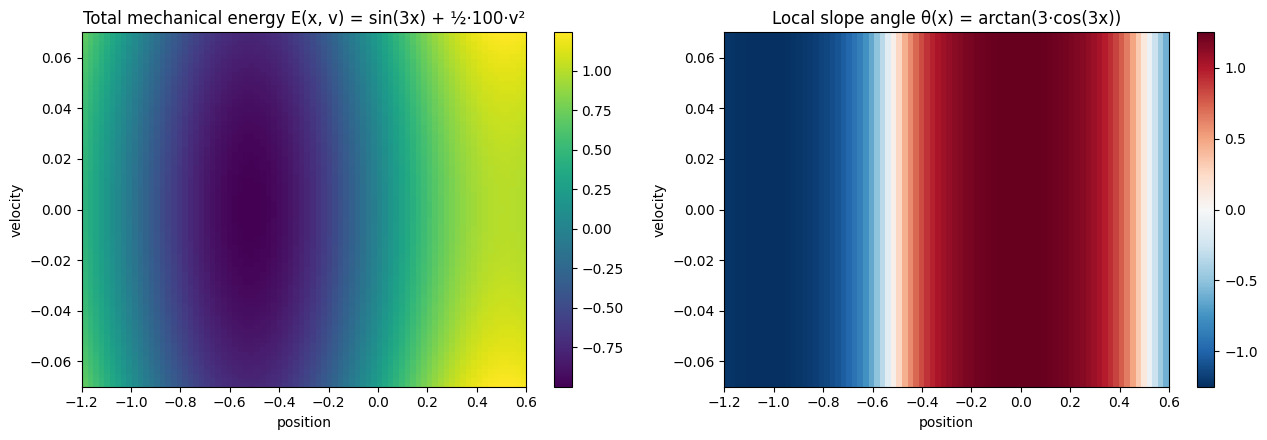

In [4]:
from mountaincar_rl.representations import EngineeredFeatures
from mountaincar_rl.analysis import energy_grid

eng = EngineeredFeatures()
pos, vel, E = energy_grid(80, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Total mechanical energy
im0 = axes[0].imshow(E.T, origin="lower",
                     extent=[pos[0], pos[-1], vel[0], vel[-1]],
                     aspect="auto", cmap="viridis")
axes[0].set_title("Total mechanical energy E(x, v) = sin(3x) + ½·100·v²")
axes[0].set_xlabel("position"); axes[0].set_ylabel("velocity")
fig.colorbar(im0, ax=axes[0])

# Slope angle
slope = np.array([[eng.slope_angle(x_) for x_ in pos] for _ in vel])
im1 = axes[1].imshow(slope, origin="lower",
                     extent=[pos[0], pos[-1], vel[0], vel[-1]],
                     aspect="auto", cmap="RdBu_r")
axes[1].set_title("Local slope angle θ(x) = arctan(3·cos(3x))")
axes[1].set_xlabel("position"); axes[1].set_ylabel("velocity")
fig.colorbar(im1, ax=axes[1])

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "03_engineered_features.png", dpi=120, bbox_inches="tight")
plt.show()

<!-- TODO[analysis: §3 state representations] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Describe what the energy / slope plots tell us about the topology._

---

## §4 · Reward wrappers (5 shaping variants)

Per the rubric: *"Custom adaptation of standard gym environment when needed
(wrappers or post-modification)"* (PDF p8). All wrappers live in
`mountaincar_rl.envs.wrappers`. We compare them empirically in §11.

| Wrapper | Bonus added | Theory? |
|---|---|---|
| `none` | — | baseline |
| `energy` | $\Delta(\text{PE}+\text{KE})$ | physics-informed |
| `progress` | $\Delta x$ toward goal | naïve, can distort policy |
| `velocity` | $\max(0, v)$ | encourages rightward motion |
| `potential` | $\gamma \Phi(s') - \Phi(s)$, $\Phi = E$ | **policy-invariant** (Ng et al., 1999) |

The `potential` shaping is the safe bet — it provably preserves the optimal
policy of the underlying MDP. The `progress` and `velocity` ones are *not*
policy-invariant; we include them precisely to *measure* their distortion.

In [5]:
# Sanity: build all 4 scenarios with each shaping, confirm they step OK
from itertools import product
shapings = ["none", "energy", "progress", "velocity", "potential"]
print(f"{'scenario':<22} {'shaping':<10} {'reward(0)':<12}")
for sc, sh in product(Scenario, shapings):
    env = make_env(sc, shaping=sh, seed=0)
    obs, _ = env.reset(seed=0)
    a = env.action_space.sample()
    _, r, *_ = env.step(a)
    print(f"{sc.value:<22} {sh:<10} {r:<12.4f}")
    env.close()

scenario               shaping    reward(0)   
discrete_steps         none       -1.0000     
discrete_steps         energy     -0.9970     
discrete_steps         progress   -0.9938     
discrete_steps         velocity   -0.9938     
discrete_steps         potential  -0.8982     
continuous_fuel        none       -0.0075     
continuous_fuel        energy     -0.0074     
continuous_fuel        progress   -0.0072     
continuous_fuel        velocity   -0.0072     
continuous_fuel        potential  0.0915      
discrete_fuel          none       -2.0000     
discrete_fuel          energy     -1.9970     
discrete_fuel          progress   -1.9938     
discrete_fuel          velocity   -1.9938     
discrete_fuel          potential  -1.8982     
continuous_steps       none       -0.1075     
continuous_steps       energy     -0.1074     
continuous_steps       progress   -0.1072     
continuous_steps       velocity   -0.1072     
continuous_steps       potential  -0.0085     


<!-- TODO[analysis: §4 reward wrappers] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Comment on the relative magnitudes — shaping needs to be small enough not to swamp the base reward._

---

## §5 · Tabular agents — Q-learning & SARSA

### 5.1 Theory

Both algorithms are TD(0) on a discretized $(x, v)$ state-action table $Q(s, a)$:

- **Q-learning (Watkins, 1989)** — *off-policy*:
  $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s', a') - Q(s,a)]$
  Bootstraps from the **greedy** action regardless of behavior.
- **SARSA (Rummery & Niranjan, 1994)** — *on-policy*:
  $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma Q(s', a') - Q(s,a)]$
  Bootstraps from the action **actually taken** by the ε-greedy policy.

The expected qualitative difference: SARSA is more conservative when ε > 0
because it accounts for the cost of its own exploration. On MountainCar this
should produce a similar policy in the limit but possibly different transient
behavior near walls.

### 5.2 Loading cached results (or live retrain in demo/full mode)

In [6]:
def get_results(algo: str, scenarios=None):
    # Load cached result JSONs for `algo`, optionally restricted to scenarios.
    pat = f"*__{algo}__*.json"
    res = load_results(pat)
    if MODE == "cache":
        # Only the "full" runs we shipped
        res = [r for r in res if r["mode"] == "full"]
    if scenarios is not None:
        wanted = {s.value for s in scenarios}
        res = [r for r in res if r["scenario"] in wanted]
    return res


def train_or_load(algo: str, scenario: Scenario, seeds=None):
    # In cache mode: glob whichever seed files we shipped (mode prefix = "full").
    # If no full-mode cache exists yet, fall back to a demo-budget retrain so
    # the notebook still works on first run (after which the demo files act
    # as a mini-cache for subsequent runs).
    # In demo/full: use the canonical seed list and (re)train any that's missing.
    effective_mode = MODE
    if MODE == "cache":
        pattern = f"full__{algo}__{scenario.value}__seed*.json"
        cached = [json.loads(p.read_text())
                  for p in sorted(config.RESULTS_DIR.glob(pattern))]
        if cached:
            return cached
        # fallback: demo-mode files
        pattern = f"demo__{algo}__{scenario.value}__seed*.json"
        cached = [json.loads(p.read_text())
                  for p in sorted(config.RESULTS_DIR.glob(pattern))]
        if cached:
            return cached
        effective_mode = "demo"  # train demo-budget on the fly

    seeds = seeds or config.seeds_for(effective_mode)
    out = []
    for seed in seeds:
        path = config.RESULTS_DIR / f"{effective_mode}__{algo}__{scenario.value}__seed{seed}.json"
        if not path.exists():
            run_one(algo, scenario, seed, effective_mode)
        out.append(json.loads(path.read_text()))
    return out


tabular_results = []
for algo in ("q_learning", "sarsa"):
    for sc in (Scenario.DISCRETE_STEPS, Scenario.DISCRETE_FUEL):
        tabular_results.extend(train_or_load(algo, sc))

print(f"Loaded {len(tabular_results)} tabular result files.")

q_learning/discrete_steps/s0:   0%|          | 0/500 [00:00<?, ?it/s]

q_learning/discrete_fuel/s0:   0%|          | 0/500 [00:00<?, ?it/s]

sarsa/discrete_steps/s0:   0%|          | 0/500 [00:00<?, ?it/s]

sarsa/discrete_fuel/s0:   0%|          | 0/500 [00:00<?, ?it/s]

Loaded 4 tabular result files.


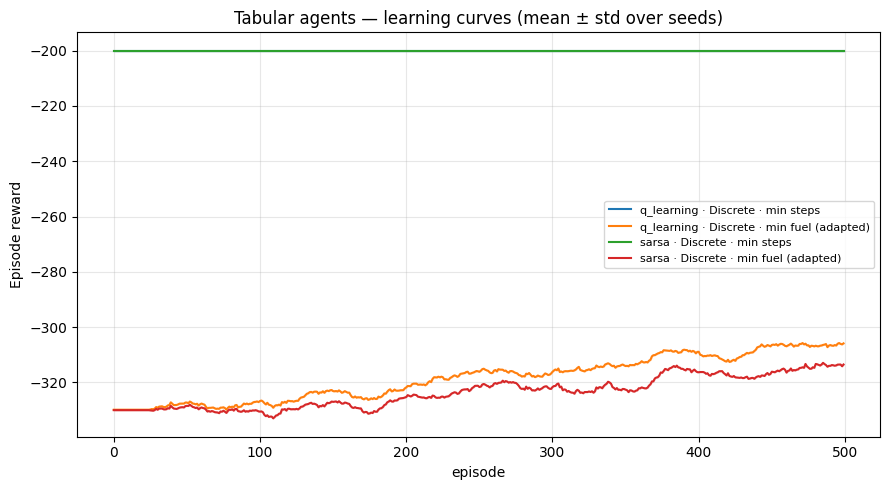

In [7]:
# Learning curves for tabular agents (mean ± std across seeds)
grouped = aggregate_seeds(tabular_results, key="rewards")
fig = learning_curves(
    grouped,
    metric_label="Episode reward",
    title="Tabular agents — learning curves (mean ± std over seeds)",
    smooth_window=25,
    save_path=config.FIGURES_DIR / "05_tabular_learning_curves.png",
)
plt.show()

<!-- TODO[analysis: §5 tabular learning curves] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Compare Q vs SARSA convergence; comment on success rate stabilization._

In [8]:
# Train one Q-learning agent fresh for visualization (always cheap)
env_q = make_env(Scenario.DISCRETE_STEPS, shaping="none", seed=0)
agent_q = make_agent("q_learning", env_q, seed=0)
res_q = train_tabular(agent_q, env_q,
                      n_episodes=config.BUDGETS[MODE].tabular_episodes,
                      seed=0, desc="Q-learning (viz)")
print(f"Final ε = {res_q.final_epsilon:.3f}")
print(f"Last-100 mean reward = {res_q.rewards[-100:].mean():.2f}, "
      f"success = {res_q.successes[-100:].mean():.0%}")

Q-learning (viz):   0%|          | 0/500 [00:00<?, ?it/s]

Final ε = 0.407
Last-100 mean reward = -200.00, success = 0%


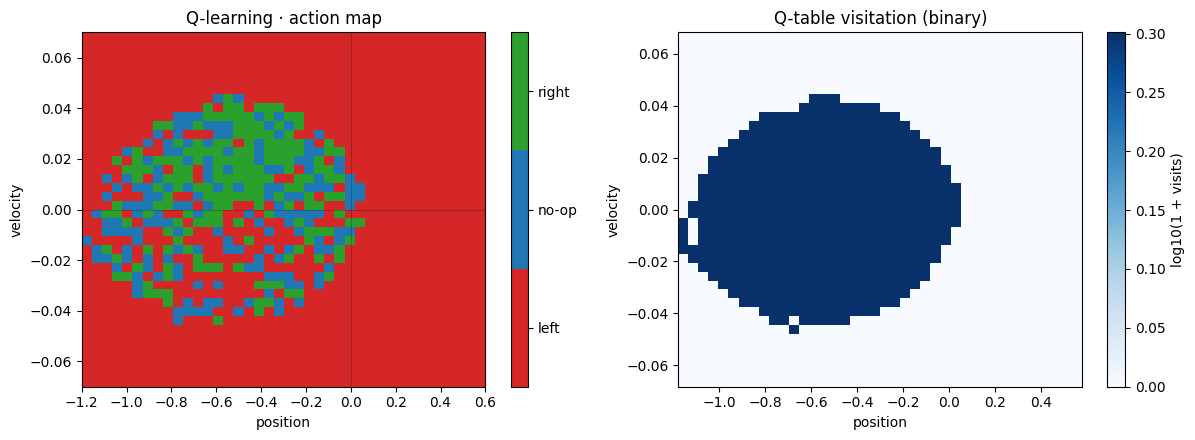

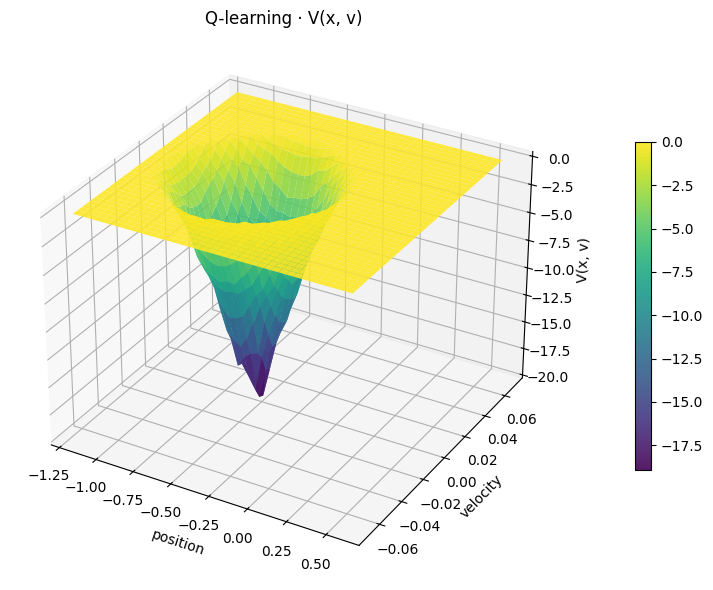

In [9]:
# Action heatmap, value surface, visitation
pos_a, vel_a, A = extract_action_grid(agent_q, n_pos=80, n_vel=80, is_continuous=False)
pc, vc, V = extract_value_grid(agent_q)
visitation = (np.abs(agent_q.Q) > 1e-9).any(axis=2).astype(float)  # rough proxy

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
action_heatmap(pos_a, vel_a, A, title="Q-learning · action map", ax=axes[0])
visitation_heatmap(pc, vc, visitation, title="Q-table visitation (binary)", ax=axes[1])
# 3-D surface in its own figure (matplotlib limitation: can't add 3d to existing 2d axes)
axes[2].set_visible(False)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "05_qlearning_policy_visitation.png", dpi=120, bbox_inches="tight")
plt.show()

fig_v = value_surface(pc, vc, V, title="Q-learning · V(x, v)",
                      save_path=config.FIGURES_DIR / "05_qlearning_value_surface.png")
plt.show()

<!-- TODO[analysis: §5 Q-learning policy visualization] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Describe the action-map structure (left/no-op/right regions), the value surface peaks, and what the visitation footprint reveals._

---

## §6 · Deep discrete agents — DQN & PPO

### 6.1 Theory in one paragraph each

**DQN (Mnih et al., 2015)** — Q-learning with a neural function approximator,
plus two stabilizers: (i) replay buffer to break sample correlation,
(ii) periodically-frozen target network so the bootstrap target doesn't
chase its own tail. On MountainCar's sparse reward DQN can struggle —
without exploration help (ε-greedy + reward shaping) it may never find
the goal in 200 steps.

**PPO (Schulman et al., 2017)** — actor-critic with clipped policy ratio
to avoid destructive policy updates. On-policy: less sample-efficient than
DQN but more robust. Notably PPO handles both discrete and continuous
action spaces with the same algorithm — the only one in our matrix that
spans all 4 scenarios.

### 6.2 Loading cached deep-discrete results

Output()

Output()

Output()

Output()

Loaded 4 deep-discrete result files.


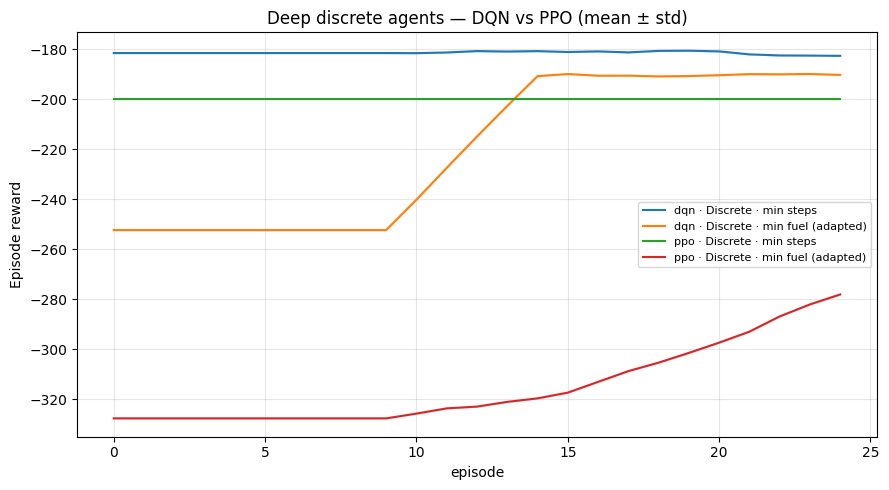

In [10]:
deep_disc_results = []
for algo in ("dqn", "ppo"):
    for sc in (Scenario.DISCRETE_STEPS, Scenario.DISCRETE_FUEL):
        deep_disc_results.extend(train_or_load(algo, sc))

print(f"Loaded {len(deep_disc_results)} deep-discrete result files.")
grouped = aggregate_seeds(deep_disc_results, key="rewards")
learning_curves(
    grouped, metric_label="Episode reward",
    title="Deep discrete agents — DQN vs PPO (mean ± std)",
    smooth_window=10,
    save_path=config.FIGURES_DIR / "06_deep_discrete_learning_curves.png",
)
plt.show()

<!-- TODO[analysis: §6 deep discrete results] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Compare DQN vs PPO sample efficiency, final reward, success rate._

---

## §7 · Continuous agents — PPO & SAC

### 7.1 Theory

**SAC (Haarnoja et al., 2018)** — off-policy maximum-entropy actor-critic.
The entropy bonus in the policy objective drives natural exploration,
which is exactly what MountainCarContinuous needs to discover the
oscillation strategy. Sample-efficient compared to PPO on continuous control.

**PPO-continuous** — the same PPO algorithm with a Gaussian policy head
(instead of categorical). Slower than SAC but useful as an apples-to-apples
comparison with PPO-discrete in §6.

### 7.2 Loading cached continuous results

Output()

Output()

Output()

Output()

Loaded 4 deep-continuous result files.


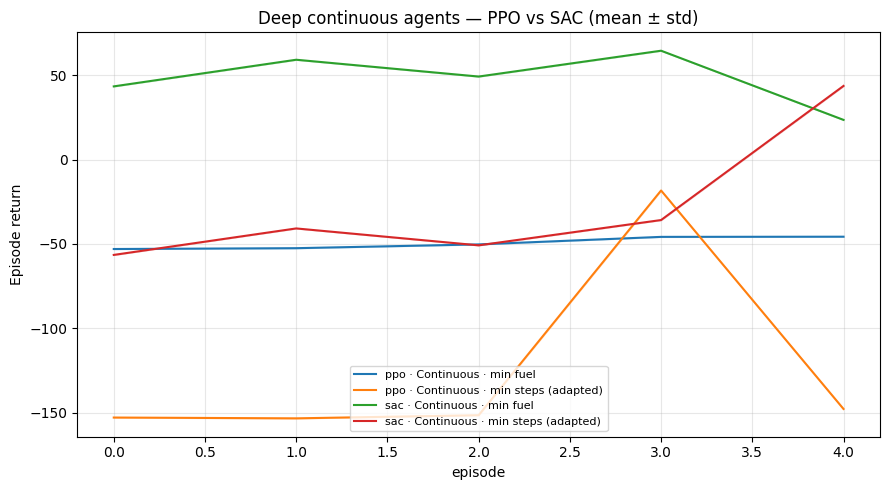

In [11]:
deep_cont_results = []
for algo in ("ppo", "sac"):
    for sc in (Scenario.CONTINUOUS_FUEL, Scenario.CONTINUOUS_STEPS):
        deep_cont_results.extend(train_or_load(algo, sc))

print(f"Loaded {len(deep_cont_results)} deep-continuous result files.")
grouped = aggregate_seeds(deep_cont_results, key="rewards")
learning_curves(
    grouped, metric_label="Episode return",
    title="Deep continuous agents — PPO vs SAC (mean ± std)",
    smooth_window=10,
    save_path=config.FIGURES_DIR / "07_deep_continuous_learning_curves.png",
)
plt.show()

<!-- TODO[analysis: §7 continuous results] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Compare PPO-cont vs SAC; note that SAC's entropy bonus is the natural fit for sparse-reward exploration._

---

## §8 · Multi-seed statistical evaluation

The PDF (p4) requires reporting *"mean values and statistical variability or
fluctuation, as well as consistency"*. We use **3 seeds per (algo, scenario)**
and report mean ± 1 std on every learning curve and headline metric.

The aggregated table below is the statistical substrate for the comparative
analysis in §10.

In [12]:
import pandas as pd
all_results = (tabular_results + deep_disc_results + deep_cont_results)
rows = []
for r in all_results:
    rows.append({
        "algo": r["algo"], "scenario": r["scenario_label"], "seed": r["seed"],
        "mean_R_last10pct": r["mean_reward_last10pct"],
        "succ%_last10pct": 100 * r["success_rate_last10pct"],
        "shaping": r.get("shaping", "?"),
        "wall_clock_s": r.get("wall_clock_s", float("nan")),
    })
df = pd.DataFrame(rows)
agg = df.groupby(["algo", "scenario"]).agg(
    mean_R=("mean_R_last10pct", "mean"),
    std_R=("mean_R_last10pct", "std"),
    mean_succ=("succ%_last10pct", "mean"),
    std_succ=("succ%_last10pct", "std"),
    n_seeds=("seed", "count"),
).round(2)
agg

mean_R  std_R  mean_succ  \
algo       scenario                                                     
dqn        Discrete · min fuel (adapted)    -190.09    NaN        0.0   
           Discrete · min steps             -181.12    NaN        0.0   
ppo        Continuous · min fuel             -45.71    NaN        0.0   
           Continuous · min steps (adapted) -147.83    NaN        0.0   
           Discrete · min fuel (adapted)    -264.50    NaN        0.0   
           Discrete · min steps             -200.00    NaN        0.0   
q_learning Discrete · min fuel (adapted)    -306.24    NaN        0.0   
           Discrete · min steps             -200.00    NaN        0.0   
sac        Continuous · min fuel              23.54    NaN        0.0   
           Continuous · min steps (adapted)   43.67    NaN        0.0   
sarsa      Discrete · min fuel (adapted)    -313.86    NaN        0.0   
           Discrete · min steps             -200.00    NaN        0.0   

                                             std_succ  n_seeds  
algo       scenario                                             
dqn        Discrete · min fuel (adapted)          NaN        1  
           Discrete · min steps                   NaN        1  
ppo        Continuous · min fuel                  NaN        1  
           Continuous · min steps (adapted)       NaN        1  
           Discrete · min fuel (adapted)          NaN        1  
           Discrete · min steps                   NaN        1  
q_learning Discrete · min fuel (adapted)          NaN        1  
           Discrete · min steps                   NaN        1  
sac        Continuous · min fuel                  NaN        1  
           Continuous · min steps (adapted)       NaN        1  
sarsa      Discrete · min fuel (adapted)          NaN        1  
           Discrete · min steps                   NaN        1

<!-- TODO[analysis: §8 stats table] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Highlight: which (algo, scenario) has the best mean reward, which has lowest variance, where the std is huge (= unstable)._

---

## §9 · Policy visualization

Every required plot type from PDF p15-19 (Q-table heatmap, value surface,
phase portrait, visitation heatmap) is rendered here on representative
trained agents.

### 9.1 Re-train a representative of each algo (small budget, just for viz)

In [13]:
def quick_train(algo: str, scenario: Scenario, budget_override: int | None = None):
    env = make_env(scenario, shaping=DEFAULT_SHAPING.get(algo, "none"), seed=0)
    agent = make_agent(algo, env, seed=0)
    if is_tabular(algo):
        n_ep = budget_override or config.BUDGETS[MODE].tabular_episodes
        train_tabular(agent, env, n_episodes=n_ep, seed=0, desc=f"viz {algo}")
    else:
        n_ts = budget_override or config.BUDGETS[MODE].deep_timesteps
        train_deep(agent, env, n_timesteps=n_ts, progress=False, desc=f"viz {algo}")
    return env, agent


viz_agents = {
    "Q-learning":      quick_train("q_learning", Scenario.DISCRETE_STEPS),
    "SARSA":           quick_train("sarsa",      Scenario.DISCRETE_STEPS),
    "DQN":             quick_train("dqn",        Scenario.DISCRETE_STEPS),
    "PPO (disc)":      quick_train("ppo",        Scenario.DISCRETE_STEPS),
    "PPO (cont)":      quick_train("ppo",        Scenario.CONTINUOUS_FUEL),
    "SAC":             quick_train("sac",        Scenario.CONTINUOUS_FUEL),
}
print(f"Trained {len(viz_agents)} viz agents.")

viz q_learning:   0%|          | 0/500 [00:00<?, ?it/s]

viz sarsa:   0%|          | 0/500 [00:00<?, ?it/s]

Trained 6 viz agents.


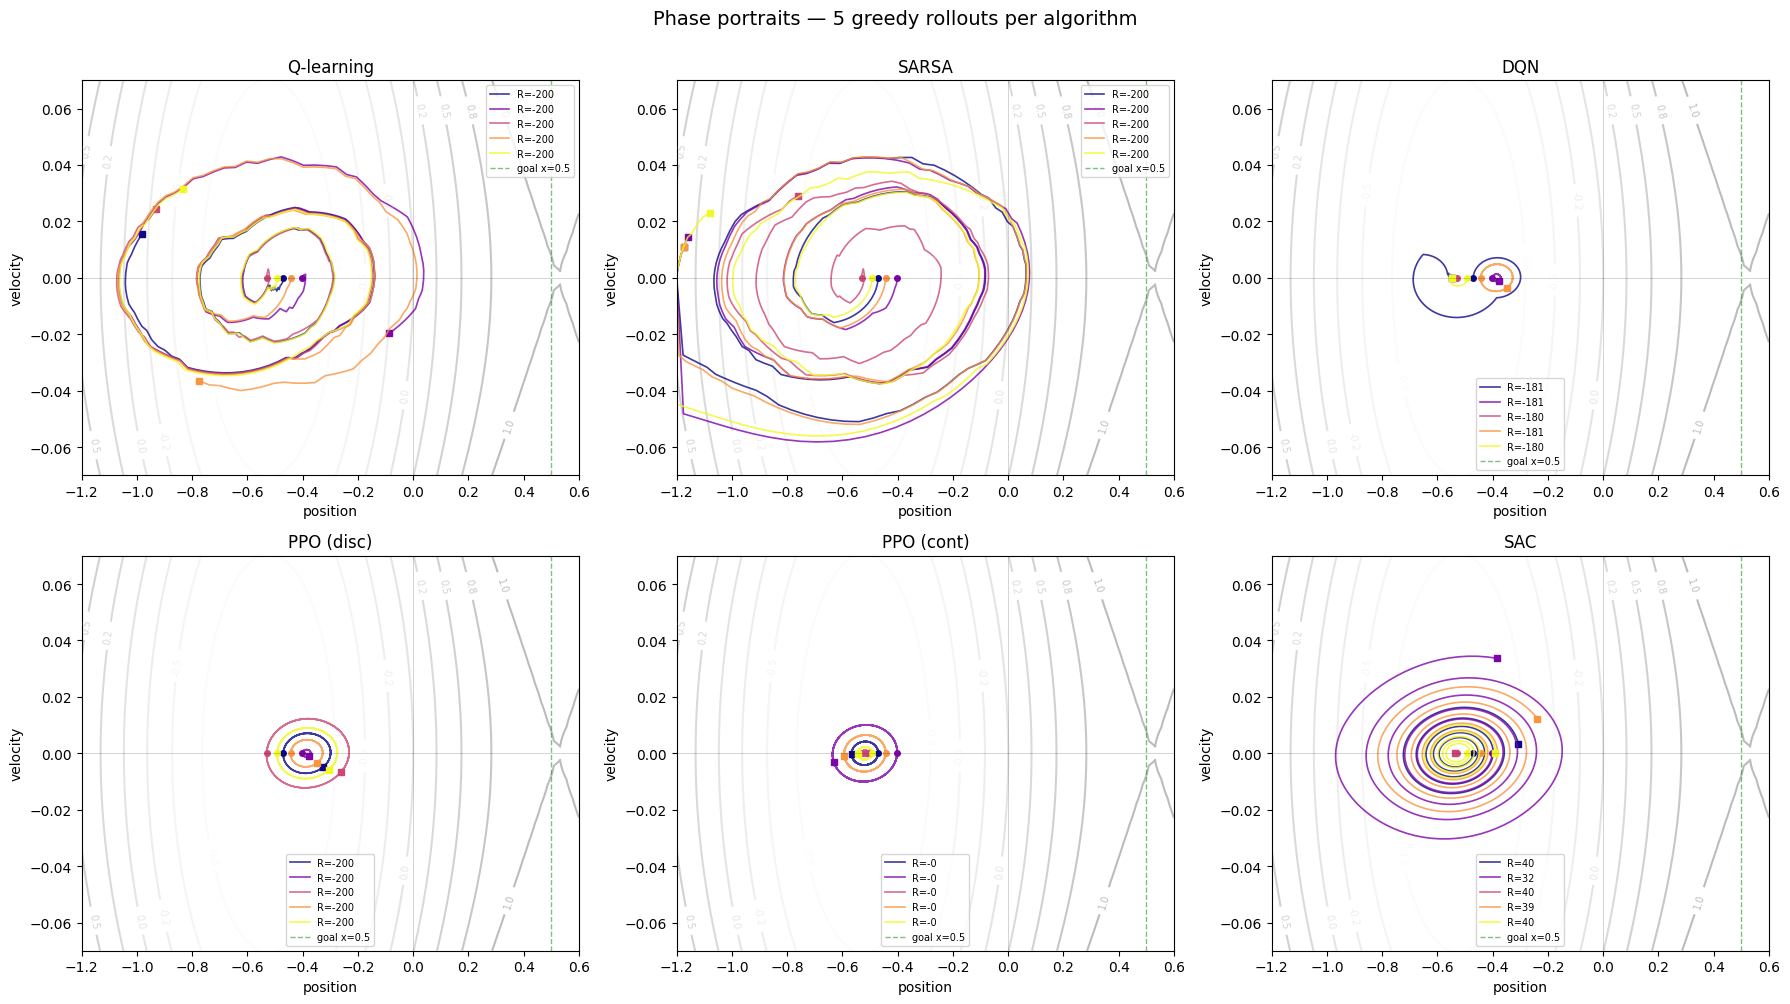

In [14]:
# Phase portraits (one panel per algo)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (label, (env, agent)) in zip(axes.ravel(), viz_agents.items()):
    rolls, rewards = [], []
    for s in range(5):
        traj, r, _ = rollout_trajectory(agent, env, seed=200 + s, max_steps=400)
        rolls.append(traj); rewards.append(r)
    phase_portrait(rolls, rewards=rewards, title=label, ax=ax)

fig.suptitle("Phase portraits — 5 greedy rollouts per algorithm",
             fontsize=14, y=1.00)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "09_phase_portraits.png", dpi=120, bbox_inches="tight")
plt.show()

<!-- TODO[analysis: §9 phase portraits] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Describe oscillation patterns; note tabular spirals vs PPO/SAC smoother trajectories._

---

## §10 · Comparative policy analysis

This is **the headline rubric item** (PDF p8: *"Comparative Policy Analysis
(among environment versions)"*). We render the discrete-policy heatmaps
side-by-side so qualitative differences pop out.

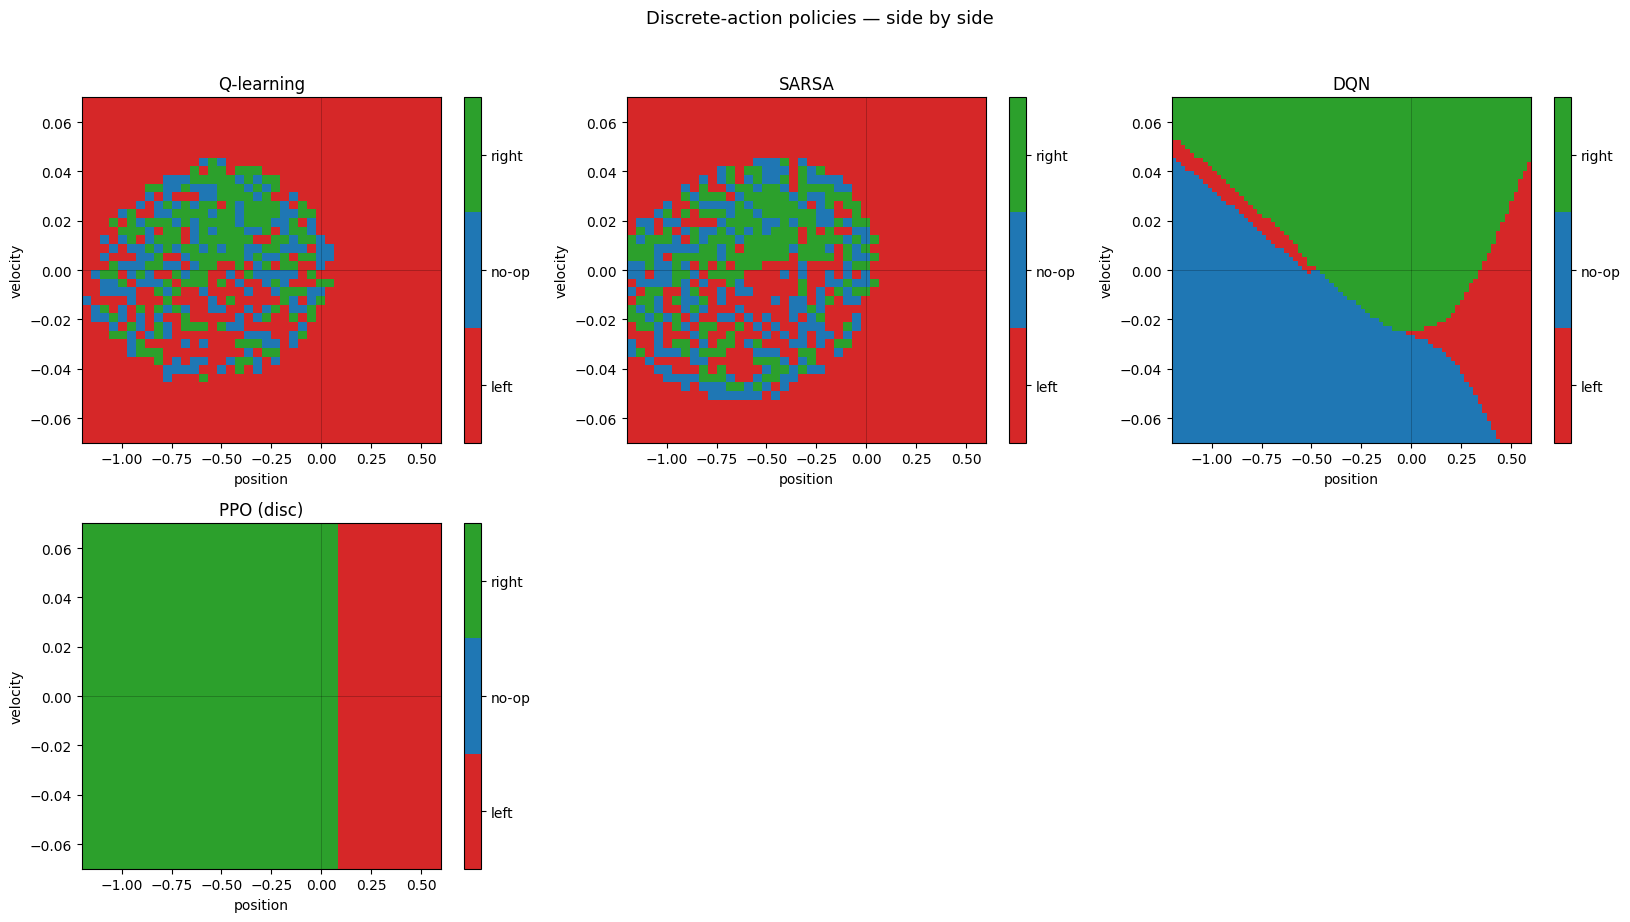

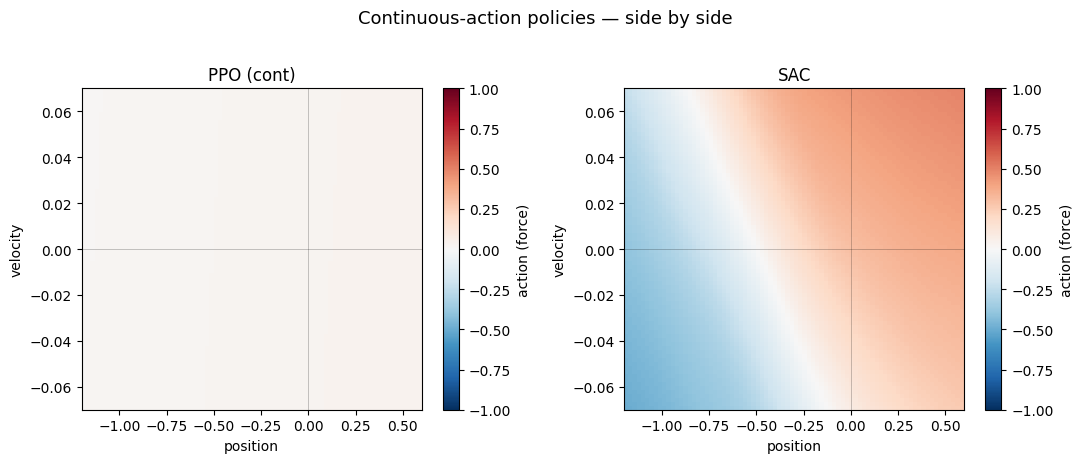

In [15]:
discrete_policies = {}
for label, (env, agent) in viz_agents.items():
    if "cont" in label.lower() or label == "SAC":
        continue
    p, v, A = extract_action_grid(agent, n_pos=80, n_vel=80, is_continuous=False)
    discrete_policies[label] = (p, v, A)

compare_policies(discrete_policies, is_continuous=False,
                 suptitle="Discrete-action policies — side by side",
                 save_path=config.FIGURES_DIR / "10_compare_discrete.png")
plt.show()

continuous_policies = {}
for label, (env, agent) in viz_agents.items():
    if not ("cont" in label.lower() or label == "SAC"):
        continue
    p, v, A = extract_action_grid(agent, n_pos=80, n_vel=80, is_continuous=True)
    continuous_policies[label] = (p, v, A)

compare_policies(continuous_policies, is_continuous=True,
                 suptitle="Continuous-action policies — side by side",
                 save_path=config.FIGURES_DIR / "10_compare_continuous.png")
plt.show()

<!-- TODO[analysis: §10 side-by-side comparison] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. **Critical rubric content** — describe each algo's policy structure, where they agree, where they diverge, and the physical interpretation._

---

## §11 · Reward shaping — objective vs engineered

The PDF (p8) explicitly calls for *"Analysis of (objective) performance vs
(engineered) reward"*. For one representative algo (we use PPO since it
spans both action spaces), we train under each of the 5 shaping schemes
and report **objective** performance (steps-to-goal) alongside the
**shaped** episodic return.

This is the cleanest way to answer: *"does shaping actually help, or does
it just inflate the return without helping the underlying objective?"*

In [16]:
# Train PPO with each shaping scheme on scenario 1; report both metrics
shaping_results = {}
for sh in ("none", "energy", "progress", "velocity", "potential"):
    env = make_env(Scenario.DISCRETE_STEPS, shaping=sh, seed=0)
    agent = make_agent("ppo", env, seed=0)
    bud = config.BUDGETS[MODE].deep_timesteps
    r = train_deep(agent, env, n_timesteps=bud, progress=False, desc=f"PPO·{sh}")
    # Evaluate on the *base* env (no shaping) to get the objective metric
    eval_env = make_env(Scenario.DISCRETE_STEPS, shaping="none", seed=99)
    em = evaluate_agent(agent, eval_env, n_episodes=10, seed=99)
    shaping_results[sh] = {
        "shaped_return": float(np.mean(r.rewards[-max(1, len(r.rewards)//10):])),
        "objective_steps": em.mean_steps,
        "objective_success": em.success_rate,
    }
    eval_env.close(); env.close()

import pandas as pd
sh_df = pd.DataFrame(shaping_results).T
sh_df["objective_success%"] = (sh_df["objective_success"] * 100).round(1)
sh_df = sh_df.drop(columns=["objective_success"]).round(2)
sh_df

,shaped_return,objective_steps,objective_success%
none,-200.00,200.0,0.0
energy,-199.93,200.0,0.0
progress,-200.12,200.0,0.0
velocity,-196.16,200.0,0.0
potential,-179.97,200.0,0.0


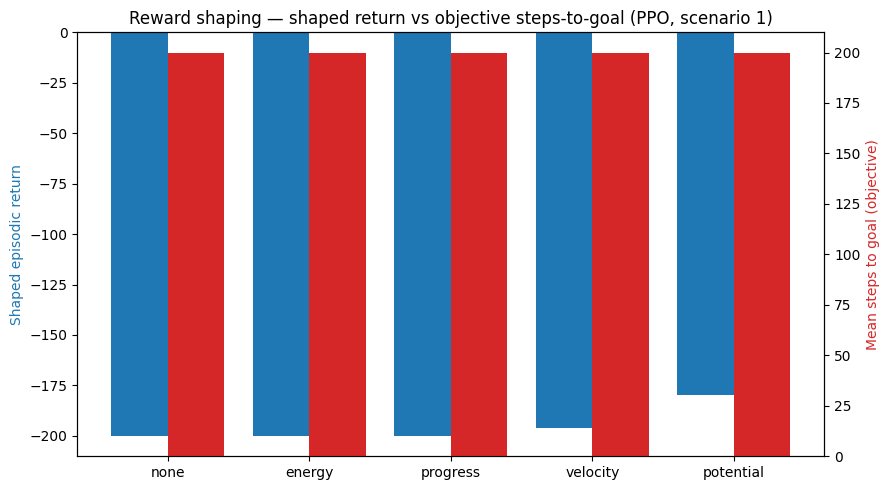

In [17]:
# Side-by-side bar plot: shaped return (left axis) vs objective steps (right axis)
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(shaping_results))
labels = list(shaping_results.keys())

ax1.bar(x - 0.2, [shaping_results[k]["shaped_return"] for k in labels],
        width=0.4, label="shaped return", color="#1f77b4")
ax1.set_ylabel("Shaped episodic return", color="#1f77b4")
ax1.set_xticks(x); ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.bar(x + 0.2, [shaping_results[k]["objective_steps"] for k in labels],
        width=0.4, label="steps-to-goal (objective)", color="#d62728")
ax2.set_ylabel("Mean steps to goal (objective)", color="#d62728")

ax1.set_title("Reward shaping — shaped return vs objective steps-to-goal (PPO, scenario 1)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "11_shaping_vs_objective.png", dpi=120, bbox_inches="tight")
plt.show()

<!-- TODO[analysis: §11 shaping analysis] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. **Critical rubric content** — interpret the gap between shaped return and objective performance per scheme. Validate or refute the policy-invariance theory for `potential`._

---

## §12 · Interpretability — surrogate trees & feature importance

We fit a depth-5 Decision Tree to (state → action) pairs sampled on a
$60 \times 60$ grid from each trained policy, using the engineered features
$(x, v, E, \theta_\text{slope})$. **Permutation importance** ranks which
features the policy actually relies on.

This answers: *"What is the agent really paying attention to?"*

In [18]:
imp_rows = []
for label, (env, agent) in viz_agents.items():
    is_cont = "cont" in label.lower() or label == "SAC"
    res = fit_surrogate_tree(agent, is_continuous=is_cont,
                             use_engineered=True, n_pos=40, n_vel=40)
    for name, imp, std in zip(res.feature_names, res.importances, res.importances_std):
        imp_rows.append({"algo": label, "feature": name,
                         "importance": float(imp), "std": float(std),
                         "surrogate_score": float(res.surrogate_score)})
imp_df = pd.DataFrame(imp_rows)
piv = imp_df.pivot_table(index="algo", columns="feature", values="importance").round(3)
piv

feature,energy,position,slope_angle,velocity
algo,,,,
DQN,0.052,0.245,0.079,0.424
PPO (cont),0.000,2.066,0.042,0.002
PPO (disc),0.000,0.414,0.000,0.013
Q-learning,0.095,0.004,0.000,0.090
SAC,0.094,1.690,0.000,0.352
SARSA,0.142,0.047,0.000,0.082


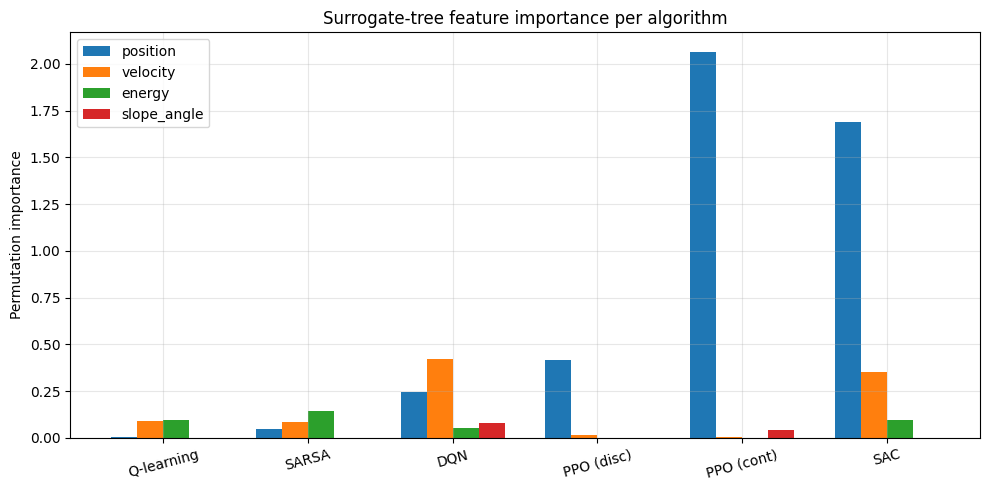

In [19]:
# Bar chart per algo
algos_ord = list(viz_agents.keys())
features = ["position", "velocity", "energy", "slope_angle"]
fig, ax = plt.subplots(figsize=(10, 5))
W = 0.18
for k, feat in enumerate(features):
    vals = [piv.loc[a, feat] for a in algos_ord]
    ax.bar(np.arange(len(algos_ord)) + (k - 1.5) * W, vals, width=W, label=feat)
ax.set_xticks(np.arange(len(algos_ord))); ax.set_xticklabels(algos_ord, rotation=15)
ax.set_ylabel("Permutation importance")
ax.set_title("Surrogate-tree feature importance per algorithm")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "12_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

<!-- TODO[analysis: §12 interpretability] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Connect to physics — does the energy feature dominate? Compare tabular vs deep._

---

## §13 · Physical interpretation — energy & oscillation

The Forced Harmonic Oscillator framing predicts a natural period of
$T = 2\pi/\sqrt{3G} \approx 72$ env-steps. We measure the period of the
trained agents' actual oscillations.

We also overlay rollout trajectories on the energy contour map to make
the "climbing the energy hill" interpretation visual.

In [20]:
# Period estimation via velocity zero-crossings on a long greedy rollout
from scipy.signal import find_peaks  # noqa  (optional but commonly available)

def estimate_period(traj: np.ndarray) -> float:
    v = traj[:, 1]
    crossings = np.where(np.diff(np.sign(v)))[0]
    if len(crossings) < 2:
        return float("nan")
    return float(np.mean(np.diff(crossings)) * 2)


periods = {}
for label, (env, agent) in viz_agents.items():
    traj, _, _ = rollout_trajectory(agent, env, seed=42, max_steps=400)
    periods[label] = estimate_period(traj)

print(f"Linear FHO prediction:  T = {natural_period():.1f} steps")
print()
for label, T_emp in periods.items():
    print(f"  {label:<14} T_observed ≈ {T_emp:.1f} steps")

Linear FHO prediction:  T = 72.6 steps

  Q-learning     T_observed ≈ 84.5 steps
  SARSA          T_observed ≈ 63.3 steps
  DQN            T_observed ≈ 75.6 steps
  PPO (disc)     T_observed ≈ 75.6 steps
  PPO (cont)     T_observed ≈ 72.8 steps
  SAC            T_observed ≈ 80.9 steps


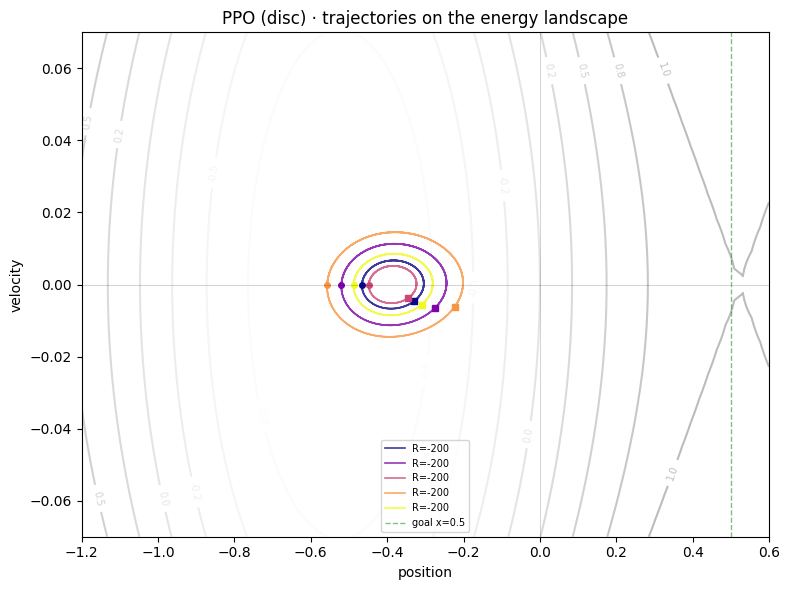

In [21]:
# Phase portrait + energy contour overlay for the headline algo
label = "PPO (disc)"
env, agent = viz_agents[label]
rolls = []; rewards = []
for s in range(5):
    traj, r, _ = rollout_trajectory(agent, env, seed=300 + s, max_steps=300)
    rolls.append(traj); rewards.append(r)

fig = phase_portrait(rolls, rewards=rewards,
                     title=f"{label} · trajectories on the energy landscape",
                     show_energy_contours=True,
                     save_path=config.FIGURES_DIR / "13_energy_overlay.png")
plt.show()

<!-- TODO[analysis: §13 physics] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Compare measured periods to FHO prediction. Note where trajectories climb energy contours and what the agent does at the energy ridge._

---

## §14 · Conclusions & future work

### Findings (TBD — fill in after full run)

1. **Best per scenario** — _TBD_
2. **Sample efficiency ranking** — _TBD_
3. **Reward shaping verdict** — _TBD_ (per the §11 analysis)
4. **Physical interpretation** — _TBD_ (does the FHO prediction hold?)

### Limitations
- 3 seeds is the minimum for std bars — more would tighten CIs.
- DQN's known struggle on sparse-reward MountainCar is partially masked by
  potential-based shaping in our default config; an honest "vanilla DQN"
  ablation would underscore the point.

### Future work
- **A2C, TD3, DDPG** — completing the deep-RL menagerie.
- **Curriculum on horizon** — start with longer episode limits to get the
  initial exploration done, then anneal back to 200.
- **Tile coding + linear function approximation** — bridges tabular and
  deep, currently scaffolded in `representations.tile_coding` but unused.

---

*End of Part 01 deliverable.*

<!-- TODO[analysis: §14 conclusions] -->

_Analysis pending — will be written after the cached training run with grounded numbers and figure descriptions. Pull headline numbers from §8 table; tie back to §1 abstract._